In [47]:
import pandas as pd
import numpy as np 

data = pd.read_csv("./data/clean_weather.csv", index_col=0)
data = data.ffill()

data

,tmax,tmin,rain,tmax_tomorrow
1970-01-01,60.0,35.0,0.0,52.0
1970-01-02,52.0,39.0,0.0,52.0
1970-01-03,52.0,35.0,0.0,53.0
1970-01-04,53.0,36.0,0.0,52.0
1970-01-05,52.0,35.0,0.0,50.0
...,...,...,...,...
2022-11-22,62.0,35.0,0.0,67.0
2022-11-23,67.0,38.0,0.0,66.0
2022-11-24,66.0,41.0,0.0,70.0
2022-11-25,70.0,39.0,0.0,62.0


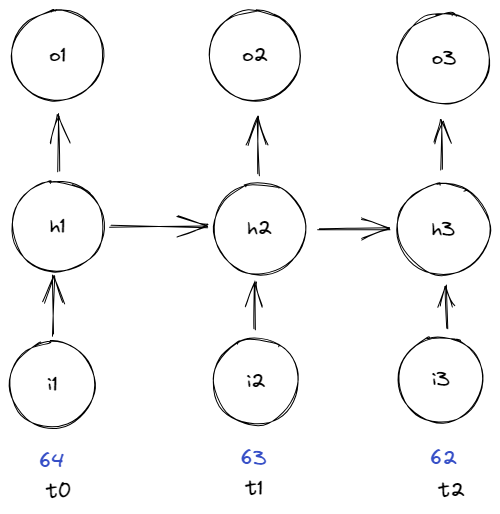

Above, we initialized our network parameters. We used the numpy random.rand function to randomly create parameter matrices of a certain shape. This network will take in a single input feature, turn it into 2 hidden features, and output one prediction.

In [ ]:
class RNN():
    def __init__(self, hidden_size, time_steps):
        self.hidden_size = hidden_size
        self.time_steps = time_steps
        
        # Get TIME_STEPS temperature values from our data
        self.x = data['tmax'].tail(time_steps).to_numpy()

    
    def InitWeights(self):
        np.random.seed(0) # Set a random seed so the numbers are the same
        n = self.hidden_size
        
        # Define our weights and biases

        # .rand(rows, columns)
        # Scale them down so values get through the tanh nonlinearity
        self.i_weight = np.random.rand(1, n) / n - .1 # Input weights connection - (1 x n)
        self.h_weight = np.random.rand(n, n) / n - .1 # Hidden to hidden weight connections - (n x n)
        self.h_bias = np.random.rand(1, n) / n - .1 # 

        # Tanh pushes values to between -1 and 1, so scale up the output weights
        self.o_weight = np.random.rand(n, 1) * (n * 10) # Output weight connections - (n x 1)
        self.o_bias = np.random.rand(1, 1) # 
    
    def ForwardPass(self, xt, prevH):
        at = self.h_bias + (xt @ self.i_weight) + (prevH @ self.h_weight)
        ht = np.tanh(at) # relu  np.maximum(0, at)
        ot = self.o_bias + (ht @ self.o_weight)
        return (ht, ot)
    
    def ForwardLoop(self):  
        ts = self.time_steps
        hs = self.hidden_size
        
        # store the previous hidden state, since we'll need it to calculate the current hidden step
        prev_hidden =  np.zeros((1, hs))

        # An array to store the output predictions
        outputs = np.zeros(ts)

        # An array to store hidden states for use in backpropagation
        hiddens = np.zeros((ts, hs))

        for i in range(ts):
            xt = self.x[i].reshape(1, 1)
            ht, ot = self.ForwardPass(xt, prev_hidden)
            
            # Updates hidden states
            prev_hidden = ht
            hiddens[i,] = ht
            
            # Stores the output prediction
            outputs[i] = ot
        print(f"Outs: {outputs}")
        print(f"Hiddens: {hiddens}")



In [62]:
rnn = RNN(hidden_size = 5,
          time_steps = 3)

rnn.InitWeights()
rnn.ForwardLoop()

/tmp/ipykernel_4871/3924735984.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  outputs[i] = ot
/tmp/ipykernel_4871/3924735984.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  outputs[i] = ot


Outs: [72.45624142 80.54746173 77.67192111]
Hiddens: [[ 0.53508939  0.99390689  0.8735109   0.54140764 -0.80193077]
 [ 0.5831071   0.99571944  0.89919326  0.69197676 -0.84136365]
 [ 0.53829491  0.99164292  0.86285078  0.66080261 -0.80542534]]
